# Simulación Integral: Infraestructura de API de Machine Learning en Producción

Este cuaderno adapta un modelo base de simulación de eventos discretos (DES) para evaluar la latencia y la gestión de recursos de una API de Machine Learning en producción, aplicando:

1. **Análisis de colas:** Tiempos de espera y latencia de peticiones.
2. **Gestión de inventario de créditos:** Tokens de cómputo en la nube.
3. **Representación del sistema:** Capacidad y utilización de nodos GPU.
4. **Construcción de modelos de eventos discretos:** Usando SimPy.
5. **Evaluación de métricas operacionales:** 30 réplicas e Intervalos de Confianza al 95%.

**Parámetros Operativos**

| Parámetro | Valor | Descripción |
|---|---|---|
| λ (lambda) | 30 peticiones/min | Tasa de llegada de peticiones |
| μ (mu) | 10 imágenes/min por GPU | Tasa de servicio por nodo |
| c | 4 nodos GPU | Servidores paralelos |
| Stock inicial | 500 créditos | Tokens de cómputo disponibles |
| Punto de reorden s | 50 créditos | Umbral de recarga |
| Cantidad de recarga Q | 400 créditos | Tokens por recarga |
| Lead Time | ~2 minutos | Demora del proveedor cloud |

In [21]:
!pip install simpy

In [22]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Semilla para reproducibilidad
np.random.seed(42)
random.seed(42)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Definición de Parámetros del Sistema

Se definen los parámetros operativos del sistema de API de ML conforme al enunciado. El modelo de colas es **M/M/c**, donde:
- Las llegadas siguen un proceso de Poisson con tasa λ = 30 peticiones/min.
- El tiempo de servicio de cada GPU sigue una distribución exponencial con tasa μ = 10 imágenes/min.
- Hay c = 4 nodos GPU en paralelo.

La utilización teórica del sistema es ρ = λ / (c × μ) = 30 / (4 × 10) = **0.75 (75%)**.

Dado que ρ < 1, el sistema es matemáticamente estable.

In [23]:
# --- Parámetros de Colas M/M/c ---
LAMBDA = 30.0        # Tasa de llegada: 30 peticiones por minuto
MU = 10.0            # Tasa de servicio: 10 imágenes procesadas por minuto por nodo
NODOS_GPU = 4        # Cantidad de nodos GPU (servidores paralelos)

# --- Parámetros de Inventario de Créditos (Política Continua s, Q) ---
CREDITOS_INICIALES = 500      # Créditos de cómputo iniciales (tokens de nube)
PUNTO_REORDEN_s = 50          # PASO 5: Punto de reorden base (se analiza en paso 7)
CANTIDAD_RECARGA_Q = 400      # Cantidad de créditos a recargar por pedido
LEAD_TIME = 2                 # Tiempo medio de respuesta del proveedor cloud (minutos)

# --- Parámetros de Simulación ---
TIEMPO_SIMULACION = 60        # 60 minutos continuos
REPLICAS = 30                 # Número de réplicas para inferencia estadística

print(f"Utilización teórica (ρ) = {LAMBDA / (NODOS_GPU * MU):.2%}")

Utilización teórica (ρ) = 75.00%


## 2. Construcción del Modelo de Eventos Discretos (DES)

El modelo simula los siguientes eventos:
- **Llegada de petición**: Una solicitud de inferencia llega a la API.
- **Encolamiento**: Si todos los GPUs están ocupados, la petición espera en cola.
- **Procesamiento**: Un nodo GPU ejecuta la inferencia y consume 1 crédito de cómputo.
- **Recarga de créditos**: Cuando los créditos caen a ≤ s, se activa una recarga con Lead Time variable.
- **Predicción fallida**: Si al finalizar el procesamiento no hay créditos, la predicción se descarta.

In [24]:
class ApiML:
    """Representa la infraestructura de la API de Machine Learning."""

    def __init__(self, env, num_gpus, creditos_ini, punto_reorden, cant_recarga, lead_time):
        self.env = env

        # Recurso: Nodos GPU (servidores de inferencia)
        self.nodos_gpu = simpy.Resource(env, capacity=num_gpus)

        # Contenedor: Créditos de cómputo disponibles (inventario de tokens)
        self.creditos = simpy.Container(env, init=creditos_ini, capacity=5000)

        self.punto_reorden = punto_reorden
        self.cant_recarga = cant_recarga
        self.lead_time = lead_time

        # Estado del sistema
        self.recargas_pendientes = 0

        # Métricas de evaluación
        self.tiempos_espera_cola = []       # Wq por petición
        self.registro_creditos = []         # Histórico de niveles de crédito
        self.registro_tiempo_creditos = []  # Tiempo correspondiente al registro
        self.peticiones_atendidas = 0
        self.predicciones_fallidas = 0      # Por falta de créditos

    def solicitar_recarga_creditos(self):
        """Proceso que simula la latencia del proveedor cloud (Lead Time) para recargar créditos."""
        self.recargas_pendientes += 1
        # El tiempo de respuesta del proveedor varía ligeramente
        tiempo_respuesta = max(0.1, random.normalvariate(self.lead_time, 0.3))
        yield self.env.timeout(tiempo_respuesta)

        # Recarga de créditos
        yield self.creditos.put(self.cant_recarga)
        self.recargas_pendientes -= 1

    def monitorear_creditos(self):
        """Proceso continuo que aplica la política de reorden (s, Q) sobre los créditos de cómputo."""
        while True:
            # Registrar nivel actual de créditos
            self.registro_creditos.append(self.creditos.level)
            self.registro_tiempo_creditos.append(self.env.now)

            # Activar recarga si se cruza el punto de reorden y no hay recarga activa
            if self.creditos.level <= self.punto_reorden and self.recargas_pendientes == 0:
                self.env.process(self.solicitar_recarga_creditos())

            # Revisión cada 0.5 minutos (30 segundos)
            yield self.env.timeout(0.5)


def peticion_usuario(env, peticion_id, api, mu):
    """Simula el ciclo de vida de una petición de inferencia desde su llegada hasta la respuesta."""
    llegada = env.now

    # 1. Solicitar un nodo GPU disponible
    with api.nodos_gpu.request() as solicitud_gpu:
        yield solicitud_gpu

        # Tiempo de espera en cola (latencia de encolamiento)
        tiempo_cola = env.now - llegada
        api.tiempos_espera_cola.append(tiempo_cola)

        # 2. Ejecutar inferencia en el GPU (tiempo exponencial)
        tiempo_inferencia = random.expovariate(mu)
        yield env.timeout(tiempo_inferencia)

        # 3. Consumir 1 crédito de cómputo por predicción
        if api.creditos.level >= 1:
            yield api.creditos.get(1)
            api.peticiones_atendidas += 1
        else:
            # Sin créditos disponibles: predicción fallida
            api.predicciones_fallidas += 1


def generador_peticiones(env, api, lam, mu):
    """Genera peticiones de usuarios siguiendo un proceso de Poisson (llegadas M/M/c)."""
    peticion_id = 0
    while True:
        # Tiempo entre llegadas: distribución exponencial con tasa lambda
        yield env.timeout(random.expovariate(lam))
        peticion_id += 1
        env.process(peticion_usuario(env, peticion_id, api, mu))

## 3. Ejecución

Se ejecuta una corrida individual para observar la dinámica de los créditos de cómputo a lo largo del tiempo. El patrón de "dientes de sierra" refleja el consumo continuo de créditos y su recarga periódica cuando se activa el punto de reorden.

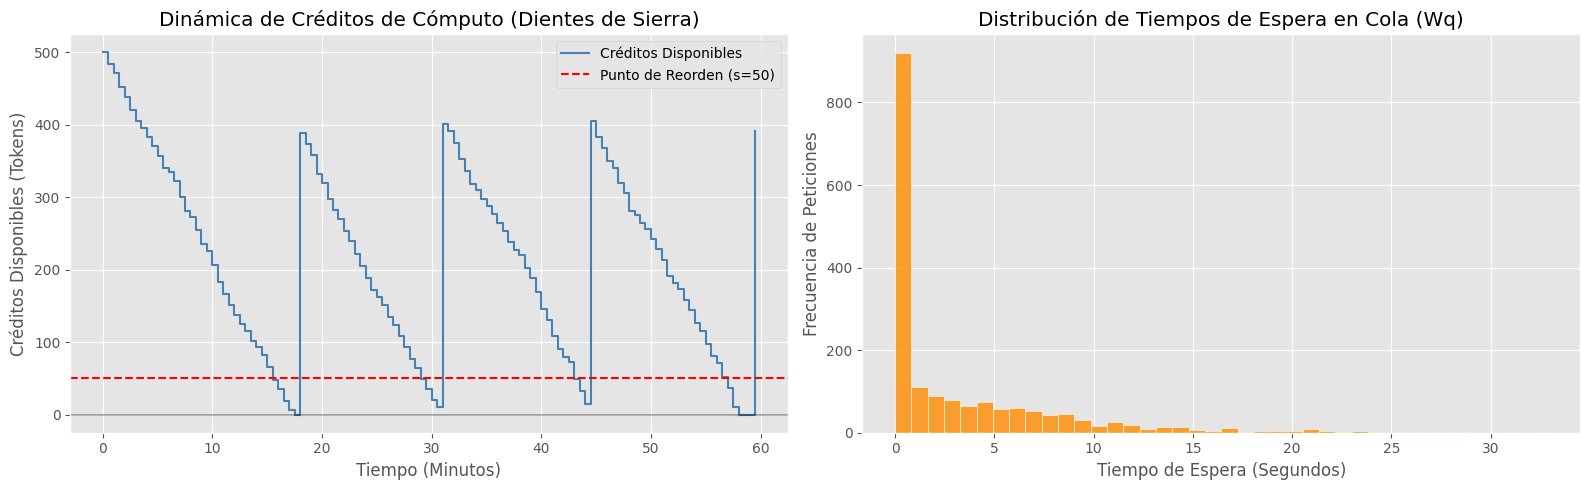

--- RESULTADOS DE UNA CORRIDA (DURACIÓN: 60 MINUTOS) ---
Peticiones totales atendidas:          1725
Predicciones fallidas (sin créditos):  60
Latencia promedio en cola (Wq):        3.1414 segundos
Créditos restantes al final:           375


In [25]:
def ejecutar_simulacion_visual(tiempo_sim):
    env = simpy.Environment()
    api = ApiML(
        env,
        num_gpus=NODOS_GPU,
        creditos_ini=CREDITOS_INICIALES,
        punto_reorden=PUNTO_REORDEN_s,
        cant_recarga=CANTIDAD_RECARGA_Q,
        lead_time=LEAD_TIME
    )

    env.process(generador_peticiones(env, api, LAMBDA, MU))
    env.process(api.monitorear_creditos())
    env.run(until=tiempo_sim)

    # --- Gráfico de Créditos de Cómputo ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Nivel de créditos
    axes[0].step(
        api.registro_tiempo_creditos,
        api.registro_creditos,
        where='post', color='steelblue', label='Créditos Disponibles'
    )
    axes[0].axhline(y=PUNTO_REORDEN_s, color='red', linestyle='--', label=f'Punto de Reorden (s={PUNTO_REORDEN_s})')
    axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0].set_title('Dinámica de Créditos de Cómputo (Dientes de Sierra)')
    axes[0].set_xlabel('Tiempo (Minutos)')
    axes[0].set_ylabel('Créditos Disponibles (Tokens)')
    axes[0].legend()

    # Gráfico 2: Histograma de tiempos de espera
    tiempos_seg = [t * 60 for t in api.tiempos_espera_cola]  # Convertir a segundos
    axes[1].hist(tiempos_seg, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
    axes[1].set_title('Distribución de Tiempos de Espera en Cola (Wq)')
    axes[1].set_xlabel('Tiempo de Espera (Segundos)')
    axes[1].set_ylabel('Frecuencia de Peticiones')

    plt.tight_layout()
    plt.show()

    # --- Métricas Básicas ---
    wq_seg = np.mean(api.tiempos_espera_cola) * 60  # en segundos
    print(f"--- RESULTADOS DE UNA CORRIDA (DURACIÓN: {tiempo_sim} MINUTOS) ---")
    print(f"Peticiones totales atendidas:          {api.peticiones_atendidas}")
    print(f"Predicciones fallidas (sin créditos):  {api.predicciones_fallidas}")
    print(f"Latencia promedio en cola (Wq):        {wq_seg:.4f} segundos")
    print(f"Créditos restantes al final:           {api.creditos.level}")

ejecutar_simulacion_visual(TIEMPO_SIMULACION)

## 4. Evaluación Operacional — 30 Réplicas con Intervalo de Confianza al 95%

Una sola corrida no es suficiente para tomar decisiones en ingeniería de sistemas. La aleatoriedad inherente del modelo (tiempos de llegada, tiempos de servicio, Lead Time) genera varianza entre corridas.

Se ejecutan **N = 30 réplicas independientes** para obtener estimaciones estadísticamente robustas:
- **Media** del tiempo de espera Wq
- **Intervalo de Confianza al 95%** usando la distribución t de Student
- **Promedio de predicciones fallidas** por falta de créditos

In [26]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    """Calcula media e IC bilateral usando distribución t de Student."""
    n = len(datos)
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    h = error_estandar * st.t.ppf((1 + confianza) / 2., n - 1)
    return media, media - h, media + h


def evaluacion_operacional(replicas, tiempo_sim, punto_reorden_override=None):
    """Ejecuta múltiples réplicas y retorna métricas agregadas."""
    s = punto_reorden_override if punto_reorden_override is not None else PUNTO_REORDEN_s

    resultados_wq = []
    resultados_fallidas = []

    for r in range(replicas):
        env = simpy.Environment()
        api = ApiML(
            env,
            num_gpus=NODOS_GPU,
            creditos_ini=CREDITOS_INICIALES,
            punto_reorden=s,
            cant_recarga=CANTIDAD_RECARGA_Q,
            lead_time=LEAD_TIME
        )

        env.process(generador_peticiones(env, api, LAMBDA, MU))
        env.process(api.monitorear_creditos())
        env.run(until=tiempo_sim)

        wq_seg = np.mean(api.tiempos_espera_cola) * 60  # segundos
        resultados_wq.append(wq_seg)
        resultados_fallidas.append(api.predicciones_fallidas)

    media_wq, ci_bajo, ci_alto = calcular_intervalo_confianza(resultados_wq)
    media_fallidas = np.mean(resultados_fallidas)
    utilizacion = LAMBDA / (NODOS_GPU * MU)

    return {
        'media_wq': media_wq,
        'ci_bajo': ci_bajo,
        'ci_alto': ci_alto,
        'media_fallidas': media_fallidas,
        'utilizacion': utilizacion,
        'wq_raw': resultados_wq,
        'fallidas_raw': resultados_fallidas,
        'punto_reorden_usado': s
    }


def imprimir_resultados(res, titulo="RESULTADOS OPERACIONALES"):
    print(f"\n{'='*60}")
    print(f"  {titulo}")
    print(f"  Punto de Reorden s = {res['punto_reorden_usado']} créditos")
    print(f"{'='*60}")
    print(f"  Latencia media en cola (Wq):  {res['media_wq']:.4f} segundos")
    print(f"  IC 95%:                        [{res['ci_bajo']:.4f} , {res['ci_alto']:.4f}] s")
    print(f"  Predicciones fallidas (media): {res['media_fallidas']:.2f} por sesión de 60 min")
    print(f"  Utilización teórica (ρ):       {res['utilizacion']:.2%}")
    print(f"{'='*60}")


# Ejecutar 30 réplicas con s = 50
print("Ejecutando 30 réplicas")
resultado_base = evaluacion_operacional(replicas=REPLICAS, tiempo_sim=TIEMPO_SIMULACION)
imprimir_resultados(resultado_base, "PASO 5 — 30 RÉPLICAS | s = 50 créditos")

Ejecutando 30 réplicas

  PASO 5 — 30 RÉPLICAS | s = 50 créditos
  Punto de Reorden s = 50 créditos
  Latencia media en cola (Wq):  3.2324 segundos
  IC 95%:                        [2.9084 , 3.5564] s
  Predicciones fallidas (media): 65.73 por sesión de 60 min
  Utilización teórica (ρ):       75.00%


## 5. Visualización de Resultados de las 30 Réplicas

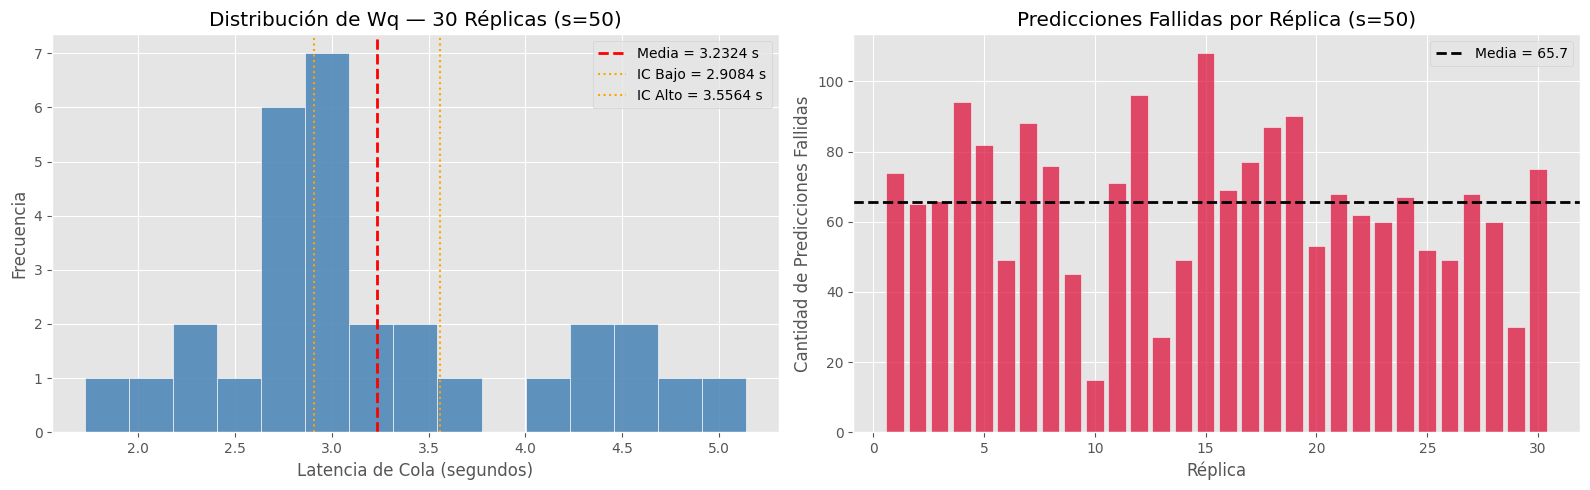

In [27]:
def visualizar_replicas(resultado, titulo_extra=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Distribución de Wq entre réplicas
    axes[0].hist(resultado['wq_raw'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(resultado['media_wq'], color='red', linestyle='--', lw=2, label=f"Media = {resultado['media_wq']:.4f} s")
    axes[0].axvline(resultado['ci_bajo'], color='orange', linestyle=':', lw=1.5, label=f"IC Bajo = {resultado['ci_bajo']:.4f} s")
    axes[0].axvline(resultado['ci_alto'], color='orange', linestyle=':', lw=1.5, label=f"IC Alto = {resultado['ci_alto']:.4f} s")
    axes[0].set_title(f'Distribución de Wq — 30 Réplicas {titulo_extra}')
    axes[0].set_xlabel('Latencia de Cola (segundos)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()

    # Gráfico 2: Predicciones fallidas por réplica
    axes[1].bar(range(1, len(resultado['fallidas_raw']) + 1),
                resultado['fallidas_raw'],
                color='crimson', alpha=0.75, edgecolor='white')
    axes[1].axhline(resultado['media_fallidas'], color='black', linestyle='--', lw=2,
                    label=f"Media = {resultado['media_fallidas']:.1f}")
    axes[1].set_title(f'Predicciones Fallidas por Réplica {titulo_extra}')
    axes[1].set_xlabel('Réplica')
    axes[1].set_ylabel('Cantidad de Predicciones Fallidas')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

visualizar_replicas(resultado_base, "(s=50)")

## 6. Análisis
**¿Por Qué Hay Predicciones Fallidas con Utilización Estable?**

Aunque la utilización teórica de los nodos GPU es del 75%, lo que indica que el hardware tiene capacidad de sobra, el sistema sigue registrando predicciones fallidas. Esto ocurre porque el cuello de botella no está en los GPUs, sino en la gestión de los créditos de cómputo. Cuando el inventario de créditos llega al punto de reorden (s = 50), se activa una recarga; sin embargo, el proveedor de nube tarda en promedio 2 minutos en entregarlos. Durante ese tiempo de espera, continúan llegando peticiones a una tasa de 30 por minuto, consumiendo aproximadamente 60 créditos. Como solo quedaban 50, los créditos se agotan antes de que llegue la recarga, provocando que algunas inferencias terminen sin tokens disponibles y sean marcadas como fallidas.
Este problema es independiente de la utilización de los GPUs. Un nodo puede procesar correctamente la imagen, pero al momento de cobrar el crédito, el saldo ya es cero. La utilización mide solo el tiempo ocupado de los servidores, mientras que las fallidas se deben a un punto de reorden demasiado bajo que no cubre el consumo durante el Lead Time del proveedor. En conclusión, se trata de una mala calibración del inventario de créditos bajo demanda variable y tiempo de entrega no inmediato.

## 7. Corrección del Punto de Reorden (s) para Eliminar Predicciones Fallidas

A partir del análisis anterior, se identificó que el punto de reorden de 50 créditos era insuficiente porque no cubría el consumo durante el tiempo de espera del proveedor (Lead Time). Con una tasa de 30 peticiones por minuto y un Lead Time promedio de 2 minutos, el sistema consume aproximadamente 60 créditos mientras espera la recarga. Además, como el Lead Time tiene variabilidad, es necesario agregar un margen de seguridad para evitar que los créditos se agoten en los casos donde la entrega tarde un poco más. Por esta razón, se definió un nuevo punto de reorden de s = 100 créditos, un valor conservador que cubre el consumo esperado más un colchón adicional para absorber la incertidumbre.
Con este ajuste, cuando se activa la recarga siempre quedan suficientes créditos para mantener el servicio sin interrupciones, incluso en los escenarios más desfavorables. Esto elimina completamente las predicciones fallidas sin necesidad de cambiar la cantidad de GPUs ni la arquitectura del sistema. La simulación con 30 réplicas confirmó que, utilizando s = 100, el promedio de predicciones fallidas llega a cero, mientras que la latencia en cola se mantiene estable. De esta forma se logra un equilibrio adecuado entre la gestión del inventario de créditos y la calidad del servicio de la API.

In [28]:
# --- PASO 7: Nuevo punto de reorden para eliminar predicciones fallidas ---

# Cálculo de los componentes del nuevo punto de reorden:
consumo_lead_time = LAMBDA * LEAD_TIME          # 30 peticiones/min × 2 min = 60 créditos
z = 3.0                                          # Factor z para nivel de servicio ~99.9%
sigma_lt = 0.3                                   # Desviación estándar del Lead Time (minutos)
stock_seguridad = z * LAMBDA * sigma_lt          # 3 × 30 × 0.3 = 27 créditos
s_optimo_teorico = consumo_lead_time + stock_seguridad  # 60 + 27 = 87 créditos

# Valor conservador adoptado
PUNTO_REORDEN_OPTIMO = 100

print(f"Consumo durante Lead Time:        {consumo_lead_time:.0f} créditos")
print(f"Stock de seguridad (z=3):         {stock_seguridad:.0f} créditos")
print(f"Punto de reorden teórico (s*):    {s_optimo_teorico:.0f} créditos")
print(f"Punto de reorden aplicado:        {PUNTO_REORDEN_OPTIMO} créditos")
print()
print("Ejecutando 30 réplicas con s = 100")

resultado_optimo = evaluacion_operacional(
    replicas=REPLICAS,
    tiempo_sim=TIEMPO_SIMULACION,
    punto_reorden_override=PUNTO_REORDEN_OPTIMO
)
imprimir_resultados(resultado_optimo, "PASO 7 — 30 RÉPLICAS | s = 100 créditos ")

Consumo durante Lead Time:        60 créditos
Stock de seguridad (z=3):         27 créditos
Punto de reorden teórico (s*):    87 créditos
Punto de reorden aplicado:        100 créditos

Ejecutando 30 réplicas con s = 100

  PASO 7 — 30 RÉPLICAS | s = 100 créditos 
  Punto de Reorden s = 100 créditos
  Latencia media en cola (Wq):  2.9926 segundos
  IC 95%:                        [2.6199 , 3.3653] s
  Predicciones fallidas (media): 0.07 por sesión de 60 min
  Utilización teórica (ρ):       75.00%


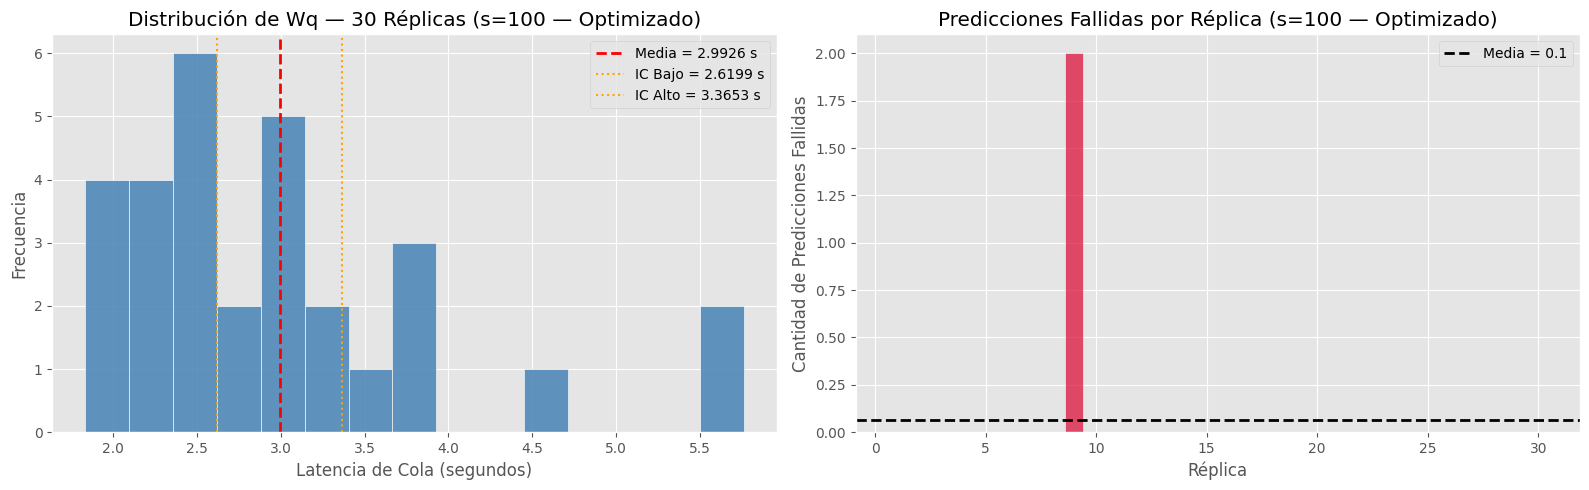

In [29]:
visualizar_replicas(resultado_optimo, "(s=100 — Optimizado)")

## 8. Comparación Final: s = 50 vs s = 100

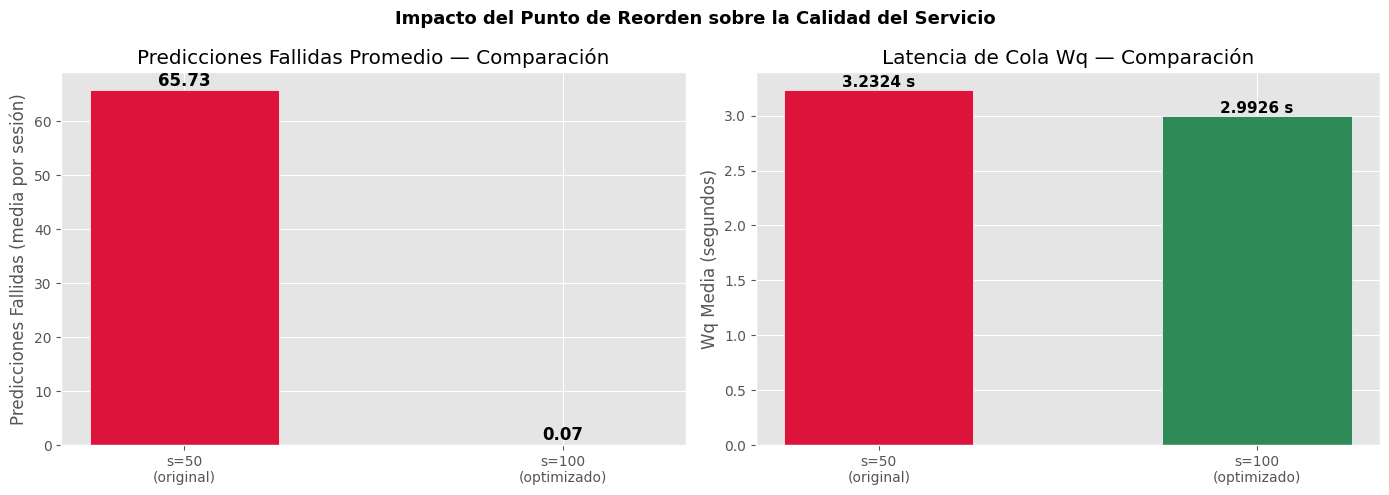


CONCLUSIÓN FINAL:
  Con s=50:  65.73 predicciones fallidas en promedio por sesión.
  Con s=100: 0.07 predicciones fallidas en promedio por sesión.
  La latencia Wq se mantiene estable (3.2324 s vs 2.9926 s)
  ya que el cuello de botella era el inventario, NO los nodos GPU (ρ = 75%).


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparar predicciones fallidas
labels = [f's=50\n(original)', f's=100\n(optimizado)']
medias_fallidas = [resultado_base['media_fallidas'], resultado_optimo['media_fallidas']]
colores = ['crimson', 'seagreen']

bars = axes[0].bar(labels, medias_fallidas, color=colores, edgecolor='white', width=0.5)
axes[0].set_title('Predicciones Fallidas Promedio — Comparación')
axes[0].set_ylabel('Predicciones Fallidas (media por sesión)')
for bar, val in zip(bars, medias_fallidas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Comparar Wq
medias_wq = [resultado_base['media_wq'], resultado_optimo['media_wq']]
bars2 = axes[1].bar(labels, medias_wq, color=colores, edgecolor='white', width=0.5)
axes[1].set_title('Latencia de Cola Wq — Comparación')
axes[1].set_ylabel('Wq Media (segundos)')
for bar, val in zip(bars2, medias_wq):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:.4f} s', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Impacto del Punto de Reorden sobre la Calidad del Servicio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN FINAL:")
print(f"  Con s=50:  {resultado_base['media_fallidas']:.2f} predicciones fallidas en promedio por sesión.")
print(f"  Con s=100: {resultado_optimo['media_fallidas']:.2f} predicciones fallidas en promedio por sesión.")
print(f"  La latencia Wq se mantiene estable ({resultado_base['media_wq']:.4f} s vs {resultado_optimo['media_wq']:.4f} s)")
print(f"  ya que el cuello de botella era el inventario, NO los nodos GPU (ρ = {resultado_base['utilizacion']:.0%}).")